In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Optional for better plot styles
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("C:/Users/LENOVO/Downloads/Google Dataset.csv")

In [4]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [5]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [7]:
df[['Close', 'Adj Close']].head()

,Close,Adj Close
Date,,
2004-08-19,2.499133,2.499133
2004-08-20,2.697639,2.697639
2004-08-23,2.724787,2.724787
2004-08-24,2.611960,2.611960
2004-08-25,2.640104,2.640104


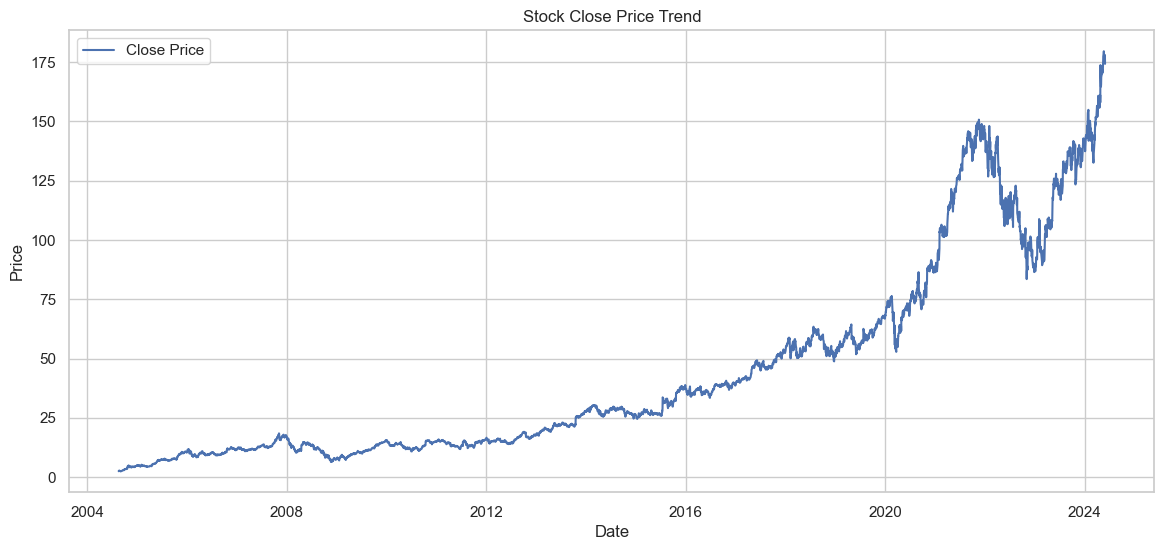

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.title("Stock Close Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [9]:
df['Close'].max(), df['Close'].idxmax()

(179.539993, Timestamp('2024-05-21 00:00:00'))

In [10]:
df['Close'].min(), df['Close'].idxmin()

(2.490913, Timestamp('2004-09-03 00:00:00'))

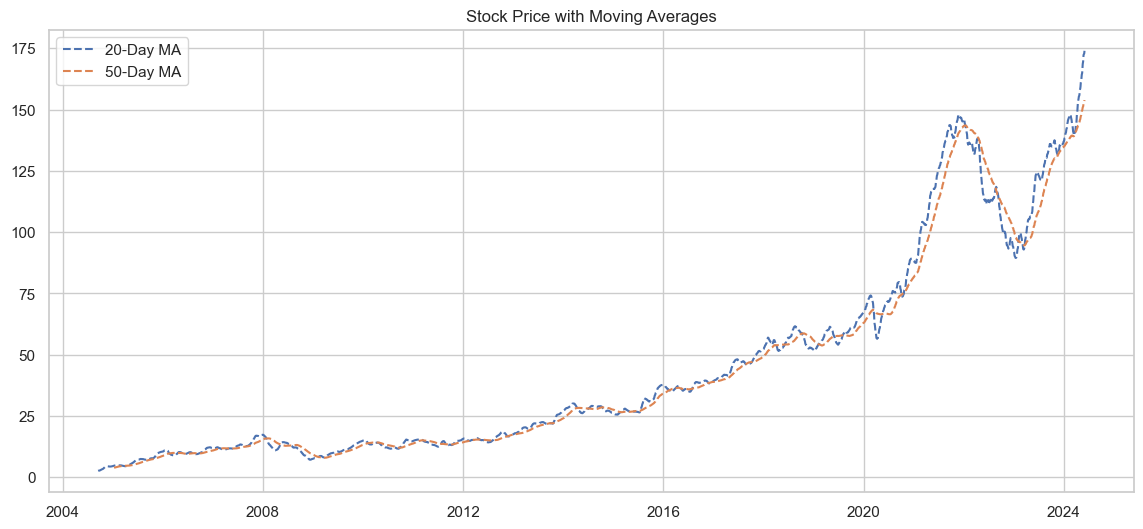

In [ ]:
df['MA20'] = df['Close'].rolling(window=20).mean()  # 20-day MA
df['MA100'] = df['Close'].rolling(window=100).mean()  # 100-day MA

plt.figure(figsize=(14,6))
# plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA20'], label='20-Day MA', linestyle='--')
plt.plot(df['MA100'], label='100-Day MA', linestyle='--')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()

In [12]:
df['Log_Close'] = np.log(df['Close'])

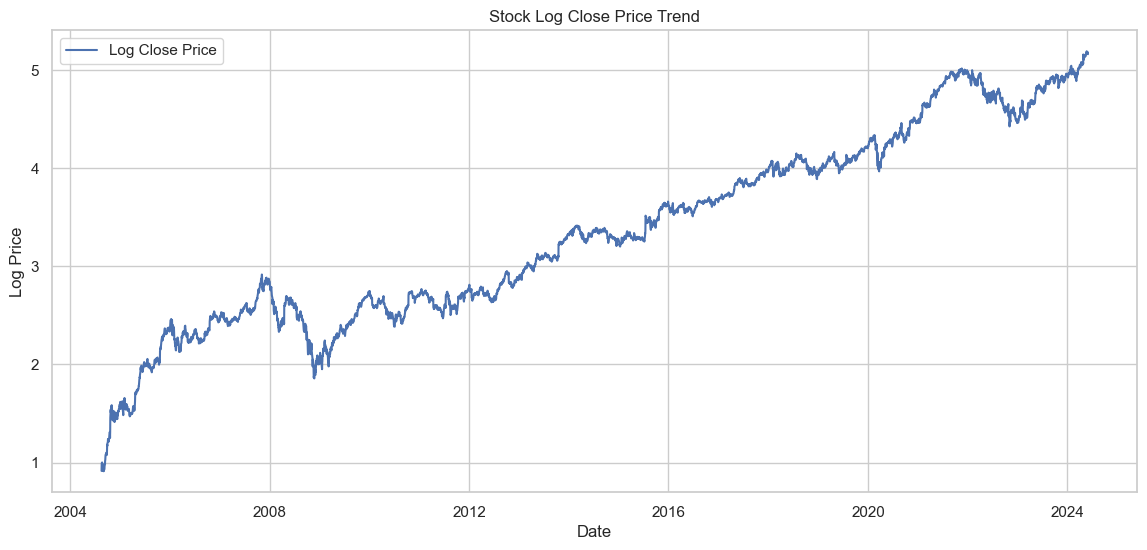

In [13]:
plt.figure(figsize=(14,6))
plt.plot(df['Log_Close'], label='Log Close Price')
plt.title("Stock Log Close Price Trend")
plt.xlabel("Date")
plt.ylabel("Log Price")
plt.legend()
plt.show()

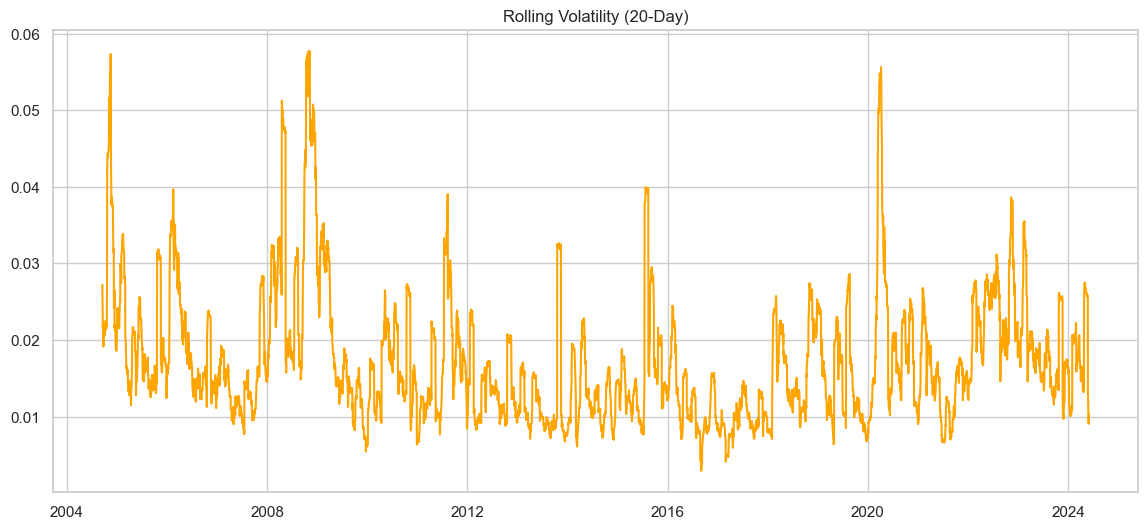

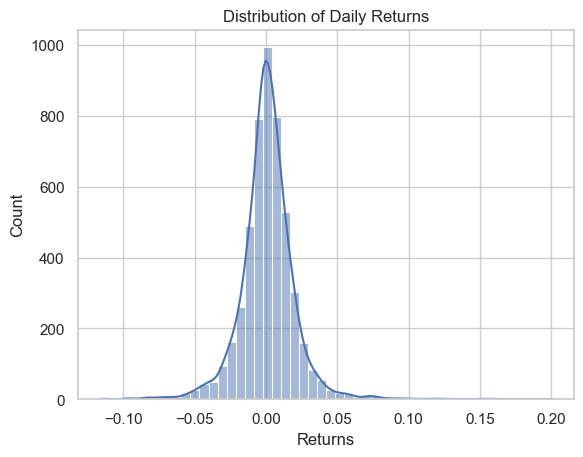

In [14]:
df['Returns'] = df['Close'].pct_change()  # daily returns
df['Volatility'] = df['Returns'].rolling(window=20).std()  # rolling volatility

plt.figure(figsize=(14,6))
plt.plot(df['Volatility'], color='orange')
plt.title("Rolling Volatility (20-Day)")
plt.show()

sns.histplot(df['Returns'].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

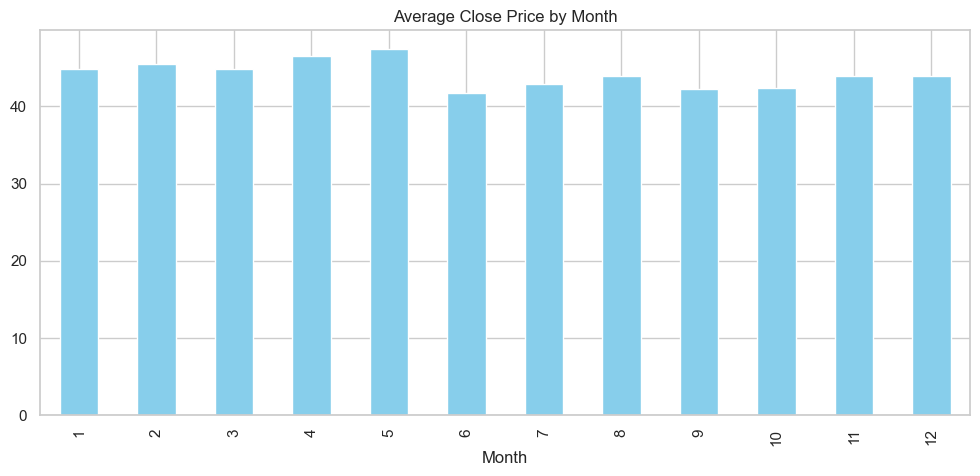

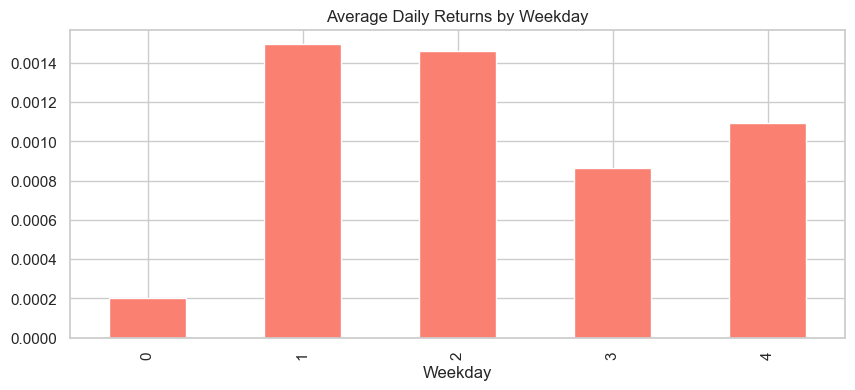

In [15]:
# Extract month, day of week
df['Month'] = df.index.month
df['Weekday'] = df.index.weekday

# Monthly average close
monthly_avg = df.groupby('Month')['Close'].mean()
monthly_avg.plot(kind='bar', figsize=(12,5), color='skyblue')
plt.title("Average Close Price by Month")
plt.show()

# Weekday average returns
weekday_avg = df.groupby('Weekday')['Returns'].mean()
weekday_avg.plot(kind='bar', figsize=(10,4), color='salmon')
plt.title("Average Daily Returns by Weekday")
plt.show()

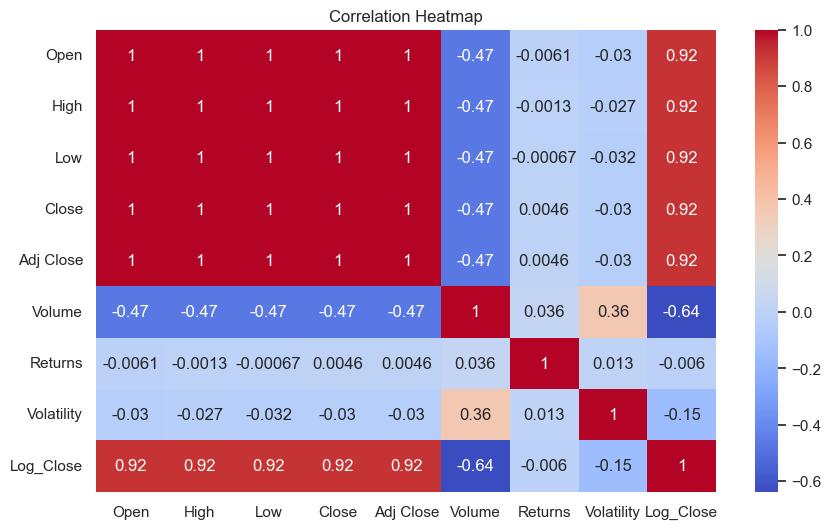

In [16]:
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Returns', 'Volatility', 'Log_Close']
plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'])])
fig.update_layout(title='Candlestick Chart', xaxis_rangeslider_visible=False)
fig.show()

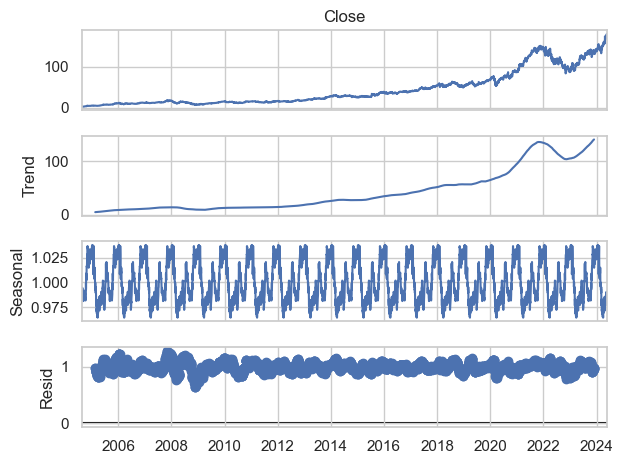

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Close'], model='multiplicative', period=252)  # ~1 year of trading days

result.plot()
plt.show()

Seasonality Analysis Observations

Seasonal decomposition (period=252 trading days) was performed as an 
exploratory step to inspect structural components of the series.
Stock price series rarely exhibit strong deterministic annual 
seasonality. The decomposition here is used to visually confirm that 
the dominant component is trend, and that any seasonal signal is weak 

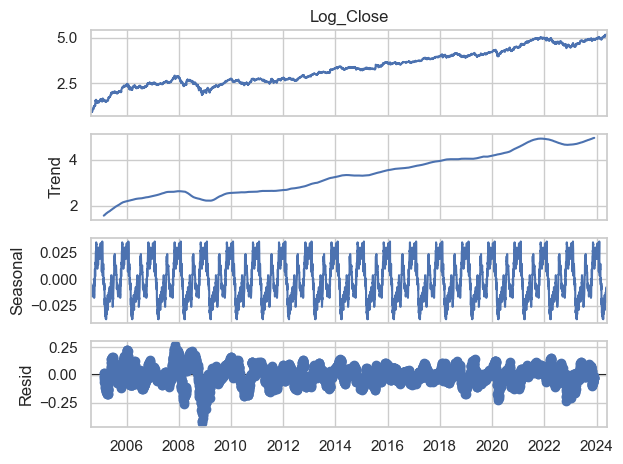

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Log_Close'], model='additive', period=252)  # ~1 year of trading days

result.plot()
plt.show()

In [20]:
from statsmodels.tsa.stattools import adfuller
from numpy import log

result = adfuller(df.Log_Close.dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -1.623638
p-value: 0.470823


In [21]:
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(df['Log_Close'], regression='ct')

print('KPSS Test Results:')
print(f'KPSS Statistic: {round(kpss_test[0],2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'    {key}: {value}')

KPSS Test Results:
KPSS Statistic: 0.67
p-value: 0.01
Critical Values:
    10%: 0.119
    5%: 0.146
    2.5%: 0.176
    1%: 0.216


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5896\2887949182.py:3: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




In [22]:
df['Log Returns'] = df['Log_Close'].diff()

In [23]:
#ADF Test after 1st order differencing
from statsmodels.tsa.stattools import adfuller
from numpy import log

result = adfuller(df['Log Returns'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -30.480219
p-value: 0.000000


In [24]:
# KPSS test after 1st order differencing
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(df['Log Returns'].dropna(), regression='ct')

print('KPSS Test Results:')
print(f'KPSS Statistic: {round(kpss_test[0],2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'    {key}: {value}')

KPSS Test Results:
KPSS Statistic: 0.1
p-value: 0.1
Critical Values:
    10%: 0.119
    5%: 0.146
    2.5%: 0.176
    1%: 0.216


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5896\1553734116.py:4: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




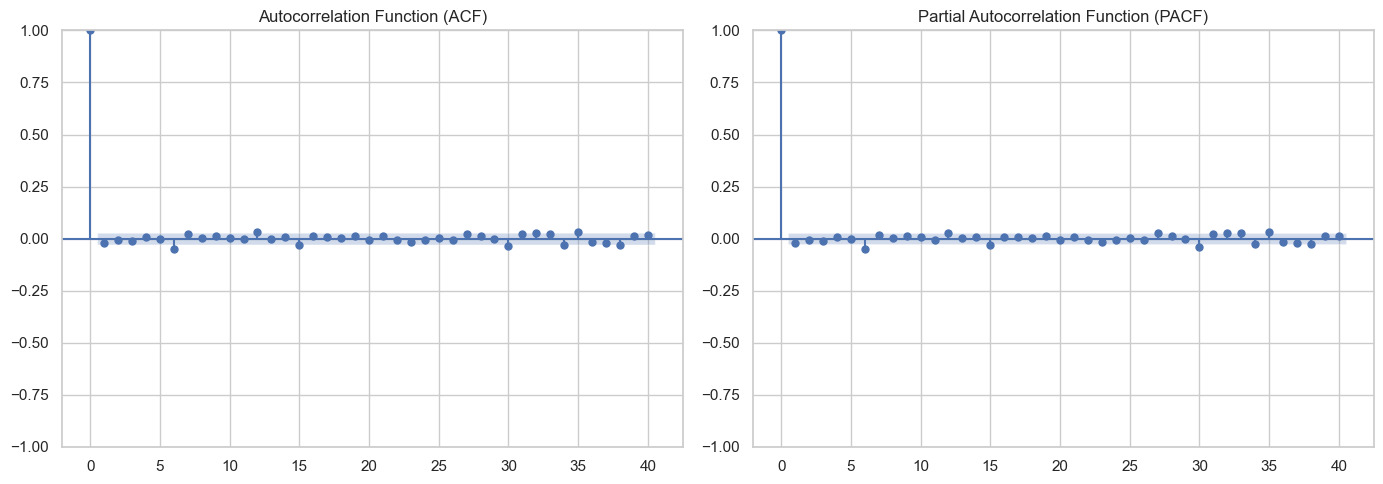

In [25]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF Plot
plot_acf(df['Log Returns'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF Plot
plot_pacf(df['Log Returns'].dropna(), lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import warnings
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings("ignore")

# Grid Search over p, q 
# d=1 already confirmed via ADF/KPSS so only searching p and q
p_values = range(0, 4)
q_values = range(0, 4)
d = 1

results_grid = []

for p, q in itertools.product(p_values, q_values):
    try:
        model = ARIMA(df['Log_Close'], order=(p, d, q), trend='t')
        fitted = model.fit()
        results_grid.append({
            'p': p, 'q': q,
            'AIC': round(fitted.aic, 2),
            'BIC': round(fitted.bic, 2)
        })
    except Exception as e:
        continue  # skip non-convergent combinations

results_df = pd.DataFrame(results_grid).sort_values('AIC').reset_index(drop=True)
print("Top 5 ARIMA combinations by AIC:")
print(results_df.head())

# Best model
best = results_df.iloc[0]
print(f"\nOptimal parameters: p={int(best.p)}, d={d}, q={int(best.q)}")
print(f"Best AIC: {best.AIC}")

Top 5 ARIMA combinations by AIC:
   p  q       AIC       BIC
0  0  1 -25200.91 -25181.37
1  1  0 -25200.88 -25181.34
2  0  0 -25200.65 -25187.63
3  1  1 -25199.18 -25173.13
4  2  0 -25199.02 -25172.97

Optimal parameters: p=0, d=1, q=1
Best AIC: -25200.91


In [27]:
# Fit the AIC-optimal model (confirmed as ARIMA(0,1,0) by grid search above)
best_p, best_q = int(results_df.iloc[0]['p']), int(results_df.iloc[0]['q'])

model  = ARIMA(df['Log_Close'], order=(best_p, d, best_q), trend='t')
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:              Log_Close   No. Observations:                 4979
Model:                 ARIMA(0, 1, 1)   Log Likelihood               12603.453
Date:                Wed, 24 Jun 2026   AIC                         -25200.907
Time:                        02:52:55   BIC                         -25181.368
Sample:                             0   HQIC                        -25194.057
                               - 4979                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0008      0.000      3.162      0.002       0.000       0.001
ma.L1         -0.0215      0.010     -2.241      0.025      -0.040      -0.003
sigma2         0.0004   3.34e-06    110.830      0.0

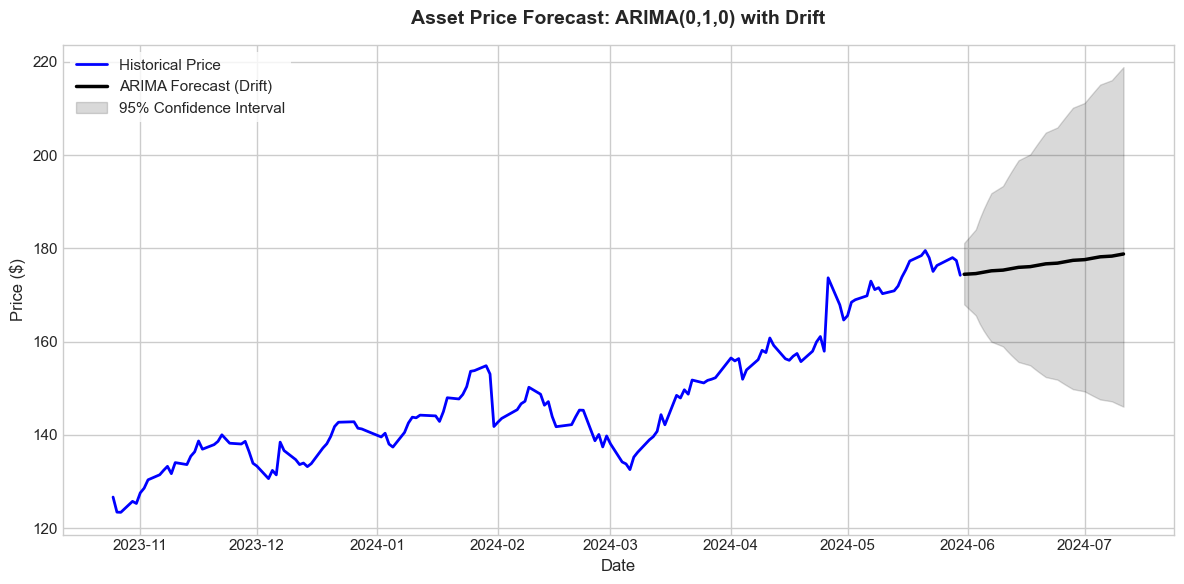

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Defined how far into future is the forecast needed
forecast_steps = 30  # 30 trading days

# 2. Generated the forecast from your statsmodels results object
forecast_obj = results.get_forecast(steps=forecast_steps)

# Extracted the log-scale mean and confidence intervals
log_forecast_mean = forecast_obj.predicted_mean
log_conf_int = forecast_obj.conf_int()

# 3. Created a proper future date index for the forecast
last_date = df.index[-1]
# If your index doesn't have an explicit frequency, generate a fresh daily/business range
forecast_index = pd.date_range(start=last_date, periods=forecast_steps + 1, freq='B')[1:]

# 4. Mapped the forecast data to the new timeline
forecast_mean_series = pd.Series(log_forecast_mean.values, index=forecast_index)
lower_ci_series = pd.Series(log_conf_int.iloc[:, 0].values, index=forecast_index)
upper_ci_series = pd.Series(log_conf_int.iloc[:, 1].values, index=forecast_index)

# 5. Converted everything back to ORIGINAL prices using np.exp()
historical_prices = np.exp(df['Log_Close'])
forecast_prices = np.exp(forecast_mean_series)
lower_prices = np.exp(lower_ci_series)
upper_prices = np.exp(upper_ci_series)

# 6. Sliced the historical data so the graph is readable
plot_history_days = 150
recent_history = historical_prices.tail(plot_history_days)

# 7. Built the Matplotlib Plot
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid') # Clean, modern look

plt.plot(recent_history.index, recent_history, label='Historical Price', color= 'blue', linewidth=2)

plt.plot(forecast_prices.index, forecast_prices, label='ARIMA Forecast (Drift)', color='black', linewidth=2.5)

plt.fill_between(forecast_prices.index, lower_prices, upper_prices, color= 'black', alpha=0.15, label='95% Confidence Interval')
plt.title('Asset Price Forecast: ARIMA(0,1,0) with Drift', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Display the chart
plt.show()

ARIMA(0,1,0) WITH DRIFT — WALK-FORWARD OUT-OF-SAMPLE METRICS
Test window : Last 60 trading days
MAE  : $2.0078
RMSE : $2.9846
MAPE : 1.25%


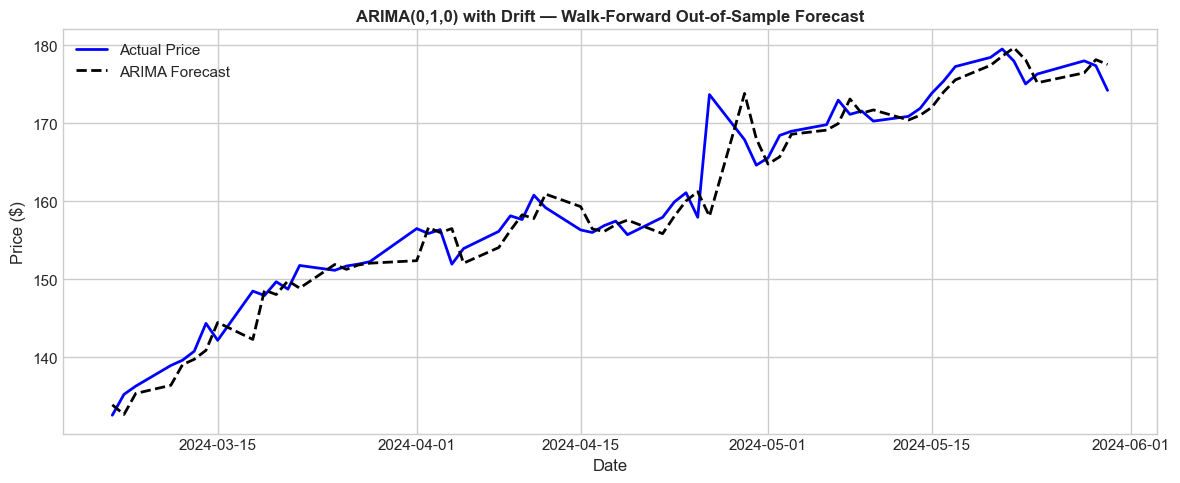

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Configuration 
TEST_SIZE = 60  # matches CNN-LSTM test window for fair comparison

# Walk-Forward Validation
log_close = df['Log_Close'].dropna()

# Split into train/test on log scale
train_log = log_close.iloc[:-TEST_SIZE]
test_log  = log_close.iloc[-TEST_SIZE:]

walk_forward_log_preds = []

for i in range(TEST_SIZE):
    # At each step, training on everything available up to that point, so the model never sees future data
    train_window = log_close.iloc[:-(TEST_SIZE - i)]

    model  = ARIMA(train_window, order=(0, 1, 0), trend='t')
    result = model.fit()

    # Predicts exactly 1 step ahead (genuine out-of-sample)
    forecast = result.forecast(steps=1)
    walk_forward_log_preds.append(forecast.iloc[0])

# Converts Back to Dollar Scale
actual_prices_oos    = np.exp(test_log.values)
predicted_prices_oos = np.exp(np.array(walk_forward_log_preds))

# Metrics computed
mae  = mean_absolute_error(actual_prices_oos, predicted_prices_oos)
rmse = np.sqrt(mean_squared_error(actual_prices_oos, predicted_prices_oos))
mape = np.mean(np.abs((actual_prices_oos - predicted_prices_oos) / actual_prices_oos)) * 100

print("ARIMA(0,1,0) WITH DRIFT — WALK-FORWARD OUT-OF-SAMPLE METRICS")
print(f"Test window : Last {TEST_SIZE} trading days")
print(f"MAE  : ${mae:.4f}")
print(f"RMSE : ${rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# Visualisation
plt.figure(figsize=(12, 5))
plt.plot(test_log.index, actual_prices_oos,    label='Actual Price',   color='blue',  linewidth=2)
plt.plot(test_log.index, predicted_prices_oos, label='ARIMA Forecast', color='black',
         linewidth=2, linestyle='--')
plt.title('ARIMA(0,1,0) with Drift — Walk-Forward Out-of-Sample Forecast', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

In [ ]:
df['Log_Close'] = np.log(df['Close'])
log_returns = df['Log_Close'].diff().dropna().values

LOOKBACK = 15
TEST_SIZE = 60

def create_sliding_windows(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

# Creates all available windows
X, y = create_sliding_windows(log_returns, LOOKBACK)

# Reshapes X to 3D: [Samples, Time Steps, Features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 3. Train/Test Split (Preserves chronological order)
X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

Training shape: (4903, 15, 1)
Testing shape:  (60, 15, 1)


In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# The hybrid architecture
model = Sequential([
    # 1. 1D CNN Layer: Sweeps across the 15-day window to extract patterns
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(LOOKBACK, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.1),
    
    # 2. LSTM Layer: Captures the long-term historical dependencies of those patterns
    LSTM(units=50, activation='tanh', return_sequences=False),
    Dropout(0.1),
    
    # 3. Output Layer: Predicts a single continuous value (tomorrow's log return)
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 13, 32)            128       
                                                                 
 max_pooling1d (MaxPooling1  (None, 6, 32)             0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 6, 32)             0         
                                                                 
 lstm (LSTM)                 (None, 50)                16600     
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                     

In [ ]:
# 1. Generated out-of-sample log return predictions
predicted_log_returns = model.predict(X_test).flatten()

# 2. Reconstructed the actual price scale
# We need the last known log prices just prior to our test window
actual_prices = df['Close'].values[-TEST_SIZE:]
previous_log_prices = df['Log_Close'].values[-(TEST_SIZE + 1):-1]

# Reconstructed the predicted Log_Close values: Today's Log Price + Predicted Return
predicted_log_close = previous_log_prices + predicted_log_returns

# Converted back to actual dollar scale using np.exp()
predicted_prices = np.exp(predicted_log_close)

2/2 [==============================] - 0s 18ms/step


In [ ]:
# Computed metrics on the original scale
cnn_lstm_mae  = mean_absolute_error(actual_prices, predicted_prices)
cnn_lstm_rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
cnn_lstm_mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
cnn_lstm_r2   = r2_score(actual_prices, predicted_prices)

print(f"CNN-LSTM BACKTEST METRICS")
print(f"MAE  : ${cnn_lstm_mae:.4f}")
print(f"RMSE : ${cnn_lstm_rmse:.4f}")
print(f"MAPE : {cnn_lstm_mape:.2f}%")
print(f"R²   : {cnn_lstm_r2:.4f}")

CNN-LSTM BACKTEST METRICS
MAE  : $2.0259
RMSE : $2.9941
MAPE : 1.26%
R²   : 0.9419
